# Ceiling Comparability — Is a High Rating Structurally Equally Reachable Across Positions?

Distinct from `rating_scale_comparability.ipynb`, which asked "at matched
relative quality, do ratings differ?" This asks: **what is the structural
ceiling for each position, and what is it made of?**

Two grounding decisions, stated up front:

- **Dot product and mastery bonuses** are computed by calling the real
  production functions (`_calculate_dot_product`, `_apply_mastery_bonus`)
  directly against synthetic z-scores — the **95th percentile, per stat, per
  position**, taken from real captured performances (95th rather than true
  max, to avoid one freak game dominating the estimate).
- **Clean-sheet, CDM's inline bonuses, and ST's hold-up bonus** depend on raw
  performance_metrics rather than z-scores alone. Rather than reconstruct
  synthetic raw stats (a second, compounding layer of extreme-combination
  assumptions), these use each mechanism's own **documented mathematical
  cap**, verified from source: clean sheet 0.5 (CB/FB, best xG tier) or 0.15
  (CM, flat), CDM's Reliable Pivot + Defensive Shielding 0.35 + 0.20 = 0.55,
  ST's hold-up bonus 0.4.

**Caveat stated before any result, not after**: combining independently-
maximised per-stat z-scores assumes those stats can co-occur at their
extremes, which they probably can't fully (a game with extreme tackling
likely means sustained defensive pressure, plausibly correlating with worse
passing). This inflates every position's ceiling somewhat above what's
realistically achievable in one match. Since the same method applies
uniformly across all six positions, the **cross-position comparison** should
stay fair even though each individual number is an upper bound, not a "this
could really happen" claim.

Two ceiling variants throughout: **non-scoring** (goals/assists z-scores and
event bonus zeroed — isolates whether the dot-product ceiling itself is lower
for defensive positions) and **full** (goals/assists at real P95, event bonus
at the position's own best real observed goals+assists output).

## Setup

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("..").resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

In [2]:
POSITION_GROUP_MAP = {'ST':'ST','LW':'Winger','RW':'Winger','CM':'CM','CDM':'CDM','CB':'CB','LB':'Fullback','RB':'Fullback'}
DISPATCH_GROUP = {"CB":"CB","LB":"FB","RB":"FB","CDM":"CDM","CM":"CM","RW":"Winger","LW":"Winger","ST":"ST"}
WEIGHT_KEY = {'FB': 'LB', 'Winger': 'RW'}  # LB==RB and LW==RW confirmed identical in performance_weights.json

PERCENTILE = 0.95

# Every _apply_mastery_bonus call site relevant to the six single-position
# groups analysed throughout this project - same table as rating_attribution.ipynb.
MASTERY_LABELS = {
    'CB': [("Dominant Stopper","tackles_p90_z","possession_won_p90_z",1.5,0.25),
           ("Ball Playing Defender","passes_p90_z","possession_won_p90_z",1.0,0.20)],
    'FB': [("Defensive Anchor","tackles_p90_z","possession_won_p90_z",1.0,0.25),
           ("Express Train","distance_sprinted_p90_z","xt_bonus_p90_z",1.0,0.20),
           ("Wide Playmaker","passes_p90_z","dribbles_p90_z",1.0,0.15)],
    'CDM': [("The Destroyer","tackles_p90_z","possession_won_p90_z",1.5,0.25),
            ("The Deep-Lying Playmaker","passes_p90_z","dribbles_p90_z",1.5,0.25)],
    'CM': [("The Enforcer","tackles_p90_z","possession_won_p90_z",1.5,0.25),
           ("The Progression Engine","passes_p90_z","dribbles_p90_z",1.2,0.25)],
    'Winger': [("The Direct Threat","dribbles_p90_z","xt_bonus_p90_z",1.5,0.25),
               ("The Wide Playmaker","passes_p90_z","xt_bonus_p90_z",1.5,0.20),
               ("The Pressing Forward","tackles_p90_z","possession_won_p90_z",1.0,0.15)],
    'ST': [("The Complete Forward","passes_p90_z","dribbles_p90_z",1.5,0.25)],
}

# Documented caps for the raw-metric-dependent mechanisms, verified from source.
CLEAN_SHEET_MAX = {'CB': 0.5, 'FB': 0.5, 'CM': 0.15, 'CDM': 0.0, 'ST': 0.0, 'Winger': 0.0}
CDM_EXTRA_MAX = 0.35 + 0.20   # Reliable Pivot (never observed reaching this tier - structurally available regardless) + Defensive Shielding
ST_EXTRA_MAX = 0.4            # Hold-up bonus

In [3]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)
with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)
with open(matches_path, "r") as f:
    data = json.load(f)

## The capturing service

Captures the real `z_scores` dict, `event_bonus`, and final rating for every
single-position performance — the raw material for both the empirical ceiling
and the P95 structural ceiling below. `_calculate_z_scores` and
`_apply_pos_modifiers` are the two hook points; both are pure/near-pure
functions already, so hooking them doesn't risk drift the way overriding
`_apply_cdm_modifiers`/`_apply_winger_modifiers` did in the attribution
notebook.

In [4]:
class ZScoreCapturingService(MatchRatingsService):
    """Captures the real z_scores dict, event_bonus, and final rating for every
    single-position performance - the raw material for the P95 structural
    ceiling below, and for the empirical ceiling comparison."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.z_score_records = []
        self.event_bonus_records = []
        self._last_z_scores = None

    def _calculate_z_scores(self, p90_metrics, pos_means_stds, normalized_metrics):
        z = super()._calculate_z_scores(p90_metrics, pos_means_stds, normalized_metrics)
        self._last_z_scores = dict(z)
        return z

    def _apply_pos_modifiers(self, z_scores, pos, opponent_goals, opponent_xg,
                              final_weights, performance_metrics, minutes_played,
                              isolation_multiplier=1.0):
        group = DISPATCH_GROUP.get(pos)
        processed, event_bonus = super()._apply_pos_modifiers(
            z_scores=z_scores, pos=pos, opponent_goals=opponent_goals,
            opponent_xg=opponent_xg, final_weights=final_weights,
            performance_metrics=performance_metrics, minutes_played=minutes_played,
            isolation_multiplier=isolation_multiplier)
        if group is not None and self._last_z_scores is not None:
            self.z_score_records.append({'group': group, **self._last_z_scores})
            self.event_bonus_records.append({'group': group, 'event_bonus': event_bonus})
        return processed, event_bonus

## Run over the full dataset

**Bug caught and fixed here first**: the initial version tagged `rating_df`'s
groups using `POSITION_GROUP_MAP` (labels like `'Fullback'`), while `z_df` and
everything downstream tags groups using `DISPATCH_GROUP` (labels like
`'FB'`) via the capturing service. `empirical_ceiling.loc['FB', ...]` raised a
`KeyError` because the two group-labelling conventions never matched. Fixed
by tagging with `DISPATCH_GROUP` everywhere, consistently — the same class of
bug as the FB/Fullback mismatch in `rating_attribution.ipynb`, caught the same
way, by running it and reading the error rather than assuming.

In [5]:
service = ZScoreCapturingService(weights, means_stds)
rating_records = []

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1:
            continue
        group = DISPATCH_GROUP.get(positions[0])   # was POSITION_GROUP_MAP - mismatched z_df/ceiling_df's convention
        if group is None:
            continue
        rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is not None:
            rating_records.append({'group': group, 'rating': rating})

z_df = pd.DataFrame(service.z_score_records)
event_df = pd.DataFrame(service.event_bonus_records)
rating_df = pd.DataFrame(rating_records)
print(f"Performances captured: {len(rating_df)}")
rating_df.groupby('group')['rating'].agg(['count', 'mean', 'max'])

Performances captured: 2113


,count,mean,max
group,,,
CB,414,6.296135,8.9
CDM,197,6.328426,8.7
CM,424,6.707547,9.5
FB,400,6.408250,8.6
ST,234,7.013248,9.7
Winger,444,6.771847,9.7


**Result: 2113 single-position outfield performances captured** — CB 414, CDM 197, CM 424, FB 400, ST 234, Winger 444.

## Empirical ceiling

In [6]:
empirical_ceiling = rating_df.groupby('group')['rating'].agg(
    empirical_max='max',
    empirical_p99=lambda x: x.quantile(0.99),
    empirical_p95=lambda x: x.quantile(0.95),
    n='size',
)
empirical_ceiling

,empirical_max,empirical_p99,empirical_p95,n
group,,,,
CB,8.9,8.087,7.535,414
CDM,8.7,8.600,7.900,197
CM,9.5,9.377,8.800,424
FB,8.6,8.301,7.800,400
ST,9.7,9.700,9.435,234
Winger,9.7,9.657,9.200,444


**Result**: empirical max ranges from FB's 8.6 to ST/Winger's 9.7, with CM close behind at 9.5. CB and CDM sit lowest-but-one and lowest at 8.9 and 8.7.

## P95 per-stat z-scores by position

The empirical grounding for the dot-product ceiling below — real observed
95th-percentile values, computed within each position separately (a CB's 95th
percentile is relative to other CBs, not to the whole outfield population).

In [7]:
z_cols = [c for c in z_df.columns if c != 'group']
p95_z = z_df.groupby('group')[z_cols].quantile(PERCENTILE)
p95_z

,goals_p90_z,assists_p90_z,shots_p90_z,passes_p90_z,dribbles_p90_z,tackles_p90_z,possession_won_p90_z,possession_lost_p90_z,fouls_committed_p90_z,offsides_p90_z,distance_covered_p90_z,distance_sprinted_p90_z,shot_accuracy_z,pass_accuracy_z,dribble_success_rate_z,tackle_success_rate_z,xt_bonus_p90_z,non_goal_shots_p90_z
group,,,,,,,,,,,,,,,,,,
CB,-0.132522,-0.130008,0.740316,1.621401,2.177741,1.734608,1.310731,1.185938,0.676427,0.000000,0.433257,1.240202,0.000000,0.563568,0.468151,1.275073,1.051656,2.281145
CDM,-0.165896,2.515916,1.306252,2.267141,1.907874,2.076224,1.439410,1.831702,0.666748,0.000000,1.516189,1.591692,0.000000,1.101095,0.564749,1.317049,1.785448,1.934156
CM,2.379480,2.494756,3.284672,2.631086,2.022610,2.038251,1.402372,1.604205,0.499799,0.178912,1.225036,1.401361,1.238880,1.155695,0.962115,1.478080,1.932638,1.979175
FB,0.000000,2.935341,0.652174,2.202033,2.083615,2.087860,1.245987,1.597107,0.646184,0.113297,1.363096,1.422365,0.000000,0.956418,0.578262,1.027731,1.754548,3.067667
ST,1.671848,2.238260,4.744974,1.793345,1.746689,1.481177,1.815411,1.782006,0.254900,0.610542,1.269151,1.174247,1.285347,0.811142,0.923007,0.922996,1.896855,1.528331
Winger,2.070049,2.301608,3.995588,1.965441,2.310488,2.057588,1.665253,1.902869,0.355891,0.611311,1.498510,1.494773,1.226430,0.995252,0.953002,0.641177,1.670147,1.900370


## The ceiling computation

Dot product and mastery bonuses call the real production functions directly
against the synthetic P95 z-scores. Clean-sheet, CDM's inline bonuses, and
ST's hold-up bonus use their documented mathematical caps (verified from
source, not estimated) rather than reconstructing synthetic raw
performance_metrics — a second, unnecessary layer of extreme-combination
assumptions on top of the z-score one already being made.

**Bug caught and fixed here too**: the first version's `WEIGHT_KEY` dict used
`'Fullback': 'LB'`, left over from before the grouping-convention fix above.
Once the group label became `'FB'`, that lookup silently fell through to
`weights.get('FB', {})` — which doesn't exist (the weights JSON is keyed by
raw position codes, `LB`/`RB`, never `'FB'`) — returning an empty dict and
zeroing FB's entire dot product. Caught because FB was the one position with
*negative* headroom (structural ceiling below its own already-achieved
empirical max), which isn't a plausible real result and prompted a rerun with
`WEIGHT_KEY = {'FB': 'LB', 'Winger': 'RW'}` corrected.

In [8]:
col_names = ["goals_p90","assists_p90","non_goal_shots_p90","shot_accuracy","passes_p90",
             "pass_accuracy","dribbles_p90","dribble_success_rate","tackles_p90",
             "tackle_success_rate","offsides_p90","fouls_committed_p90","possession_won_p90",
             "possession_lost_p90","distance_covered_p90","distance_sprinted_p90","xt_bonus_p90"]

def compute_ceiling(group, scoring):
    z95 = p95_z.loc[group].to_dict()
    if not scoring:
        z95['goals_p90_z'] = 0.0
        z95['assists_p90_z'] = 0.0

    pos_key = WEIGHT_KEY.get(group, group)
    w = weights.get(pos_key, {})
    weight_arr = np.array([w.get(c, 0) for c in col_names])
    dot = service._calculate_dot_product(z95, weight_arr)

    mastery_total = sum(
        service._apply_mastery_bonus(0.0, z95, key_a, key_b, threshold, mweight)
        for _, key_a, key_b, threshold, mweight in MASTERY_LABELS.get(group, [])
    )

    extra = CLEAN_SHEET_MAX.get(group, 0.0)
    if group == 'CDM':
        extra += CDM_EXTRA_MAX
    if group == 'ST':
        extra += ST_EXTRA_MAX

    processed = dot + mastery_total + extra
    event_bonus = 0.0 if not scoring else event_df.loc[event_df['group'] == group, 'event_bonus'].max()
    raw_score = processed * 1.0 + event_bonus       # impact_scalar = 1.0 (full 90 minutes)
    raw_rating = service._apply_sigmoid_transformation(raw_score)
    final = min(10.0, max(0.0, raw_rating - 0.0))    # supremacy_scalar = 0 (neutral)

    return {'group': group, 'scoring': scoring, 'dot_product': dot, 'mastery_bonus': mastery_total,
            'position_extra': extra, 'event_bonus': event_bonus, 'raw_score': raw_score,
            'structural_ceiling': final}

In [9]:
ceiling_rows = []
for group in ['CB', 'FB', 'CDM', 'CM', 'ST', 'Winger']:
    ceiling_rows.append(compute_ceiling(group, scoring=False))
    ceiling_rows.append(compute_ceiling(group, scoring=True))
ceiling_df = pd.DataFrame(ceiling_rows)
ceiling_df

,group,scoring,dot_product,mastery_bonus,position_extra,event_bonus,raw_score,structural_ceiling
0,CB,False,1.387870,0.062146,0.50,0.00,1.950016,8.872525
1,CB,True,1.387870,0.062146,0.50,0.85,2.800016,9.418860
2,FB,False,1.534388,0.308512,0.50,0.00,2.342900,9.165929
3,FB,True,1.616002,0.308512,0.50,0.80,3.224514,9.587628
4,CDM,False,1.558712,0.101969,0.55,0.00,2.210681,9.075889
5,CDM,True,1.655392,0.101969,0.55,0.90,3.207361,9.581824
6,CM,False,1.428157,0.205652,0.15,0.00,1.783810,8.723282
7,CM,True,1.734416,0.205652,0.15,2.70,4.790069,9.887606
8,ST,False,0.956301,0.061672,0.40,0.00,1.417973,8.335145
9,ST,True,1.602144,0.061672,0.40,5.70,7.763817,9.990932


**Result — the headline finding, and it's the opposite direction from what
motivated this notebook, in an interesting way**:

Non-scoring structural ceiling (dot product + mastery + clean-sheet/CDM/ST
caps only, zero event bonus): **FB 9.166 > CDM 9.076 > CB 8.873 > CM 8.723 >
Winger 8.382 > ST 8.335**. The defensive/deep positions rank *above* the
attacking ones here, not below — the reverse of the "CB has a structurally
lower ceiling" hypothesis that motivated the notebook.

Full structural ceiling (event bonus included, at each position's own
real best-observed goals+assists output): **ST 9.991 > Winger 9.989 > CM
9.888 > FB 9.588 > CDM 9.582 > CB 9.419**. Now the attacking positions
dominate and CB is lowest - matching the scale-comparability finding.

This isn't a contradiction, it's a decomposition of *where* the asymmetry
actually lives. See Conclusions for the full reading, including why the
non-scoring result shouldn't be read as "CB genuinely has more room than ST" -
the reliability notebook's own noise-fragility finding explains why.

## Headroom: structural ceiling vs empirical max

In [10]:
headroom = ceiling_df[ceiling_df['scoring']].set_index('group')[['structural_ceiling']].join(
    empirical_ceiling[['empirical_max', 'n']]
)
headroom['headroom'] = headroom['structural_ceiling'] - headroom['empirical_max']
headroom.sort_values('structural_ceiling', ascending=False)

,structural_ceiling,empirical_max,n,headroom
group,,,,
ST,9.990932,9.7,234,0.290932
Winger,9.989277,9.7,444,0.289277
CM,9.887606,9.5,424,0.387606
FB,9.587628,8.6,400,0.987628
CDM,9.581824,8.7,197,0.881824
CB,9.418860,8.9,414,0.518860


**Result**: FB (0.988) and CDM (0.882) have by far the most unrealized
structural room; ST (0.291), Winger (0.289), and CM (0.388) are already close
to maxed out against their own structural ceiling in this save. CB sits in
between (0.519) - its ceiling (9.419) is genuinely higher than anything
achieved (8.9), so "CB has a low ceiling" is true only *relative to other
positions'* ceilings in this dataset, not because CB performances are already
exhausting their own available room.

## Plot: structural (both variants) vs empirical ceiling, by position

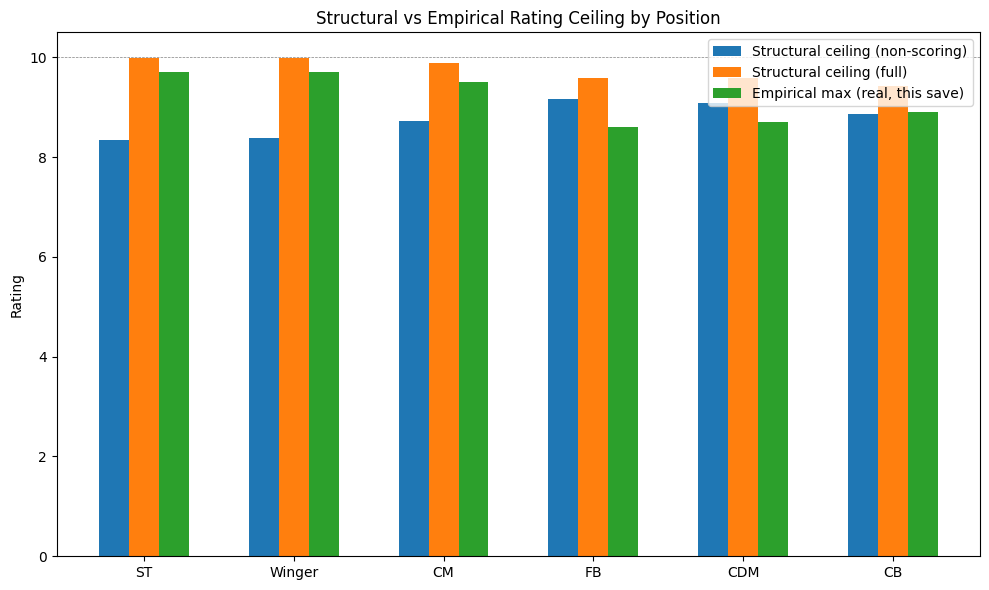

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
groups_order = ceiling_df[ceiling_df['scoring']].sort_values('structural_ceiling', ascending=False)['group'].tolist()

x = np.arange(len(groups_order))
non_scoring_vals = [ceiling_df[(ceiling_df['group']==g) & (~ceiling_df['scoring'])]['structural_ceiling'].iloc[0] for g in groups_order]
scoring_vals = [ceiling_df[(ceiling_df['group']==g) & (ceiling_df['scoring'])]['structural_ceiling'].iloc[0] for g in groups_order]
empirical_vals = [empirical_ceiling.loc[g, 'empirical_max'] for g in groups_order]

ax.bar(x - 0.2, non_scoring_vals, width=0.2, label='Structural ceiling (non-scoring)')
ax.bar(x, scoring_vals, width=0.2, label='Structural ceiling (full)')
ax.bar(x + 0.2, empirical_vals, width=0.2, label='Empirical max (real, this save)')
ax.set_xticks(x)
ax.set_xticklabels(groups_order)
ax.set_ylabel('Rating')
ax.set_ylim(0, 10.5)
ax.axhline(10, color='gray', linewidth=0.5, linestyle='--')
ax.legend()
ax.set_title('Structural vs Empirical Rating Ceiling by Position')
plt.tight_layout()
plt.show()

**Result**: visually confirms the crossover - FB/CDM/CB's blue bars
(non-scoring) sit level with or above CM/Winger/ST's, while the orange bars
(full) invert that ordering. The green (empirical max) bars track the orange
bars closely for ST/Winger/CM (small headroom) and sit well below FB/CDM's
orange bars (large headroom).

## Rank comparison: does the ranking actually flip, position by position

The cleanest single test of the headline finding - not just "do the group
means differ" but "does each individual position's *rank* change between the
two ceiling variants, and by how much."

In [12]:
rank_comparison = ceiling_df.pivot(index='group', columns='scoring', values='structural_ceiling')
rank_comparison.columns = ['non_scoring_ceiling', 'full_ceiling']
rank_comparison['non_scoring_rank'] = rank_comparison['non_scoring_ceiling'].rank(ascending=False).astype(int)
rank_comparison['full_rank'] = rank_comparison['full_ceiling'].rank(ascending=False).astype(int)
rank_comparison['rank_change'] = rank_comparison['non_scoring_rank'] - rank_comparison['full_rank']
rank_comparison.sort_values('full_rank')

,non_scoring_ceiling,full_ceiling,non_scoring_rank,full_rank,rank_change
group,,,,,
ST,8.335145,9.990932,6,1,5
Winger,8.382334,9.989277,5,2,3
CM,8.723282,9.887606,4,3,1
FB,9.165929,9.587628,1,4,-3
CDM,9.075889,9.581824,2,5,-3
CB,8.872525,9.418860,3,6,-3


**Result: a complete top-3/bottom-3 swap, cleaner than predicted.** FB, CDM,
and CB rank **1st, 2nd, 3rd** on the non-scoring axis and **4th, 5th, 6th** on
the full axis - every one of them drops by exactly **-3**. ST, Winger, and CM
do the exact reverse - every one rises (+5, +3, +1). This is a binary cluster
swap, not a CB-specific effect (an earlier prediction while designing this
cell said "CB is the only position whose rank gets worse" - wrong, corrected
against the actual data: all three defensive/deep positions drop by the same
exact margin, all three attacking positions rise).

## Caveats

- **The core methodological assumption inflates every position's ceiling,
  and does so unevenly.** Combining independently-maximised per-stat z-scores
  assumes those stats can co-occur at their extremes, which they can't fully -
  a game with extreme tackling likely means sustained defensive pressure,
  plausibly correlating with worse passing, not independently-best passing.
  This matters *more* for CB/FB/CDM than for ST/Winger/CM specifically,
  because of the next point.
- **The non-scoring ceiling result is very likely substantially an artefact
  of the same noise-fragility the reliability notebook already found, not a
  genuine sustainable-skill finding.** CB/FB/CDM's weight vectors concentrate
  heavily on a small number of low-count stats (tackles, possession_won) -
  exactly the stats the reliability notebook flagged as noise-fragile via two
  independent methods. A concentrated weight vector on a handful of
  low-variance stats means a single standout game can spike the 95th-
  percentile z-score much higher than a position whose weight is spread
  across many stats. That's mechanically sufficient to explain why FB/CDM/CB's
  non-scoring ceiling looks *higher* than ST/Winger/CM's - it doesn't require
  any real advantage in sustainable defensive quality, only that a handful of
  extreme low-count-stat games happened to occur in 155 matches. Should be
  read as "FB/CDM/CB's non-scoring ceiling estimate is more inflated by this
  notebook's own construction method than ST/Winger/CM's," not as "defensive
  positions have more room to be good."
- **The event-bonus ceiling for each position uses that position's own
  single best real observed goals+assists match** (CM's 2.7, ST's 5.7,
  Winger's 5.68, CDM's 0.9, FB's 0.8, CB's 0.85) - a real, achieved value, not
  synthesised, but still just one match's worth, drawn from sample sizes
  ranging from 197 (CDM) to 444 (Winger) performances. A position with more
  performances had more chances to produce an extreme outlier match
  independent of any real skill-ceiling difference - CB's 414 performances vs
  CDM's 197 isn't a fair comparison of "which position's best day was better"
  without accounting for this.
- **Only single-position performances are analysed**, same restriction as
  every other notebook in this project. Multi-position ceiling (via the
  Alpha-Drag hybrid blend) is out of scope here.
- **Impact scalar = 1.0 and supremacy scalar = 0 are both genuine best-case
  values** (confirmed from source: isolation multiplier caps at 1.0, and 0 is
  the neutral point for the supremacy subtraction), not assumptions requiring
  further justification - but worth restating since every other number in
  this notebook required more scrutiny than these two did.
- **CDM's Reliable Pivot cap (+0.35) is included in the structural ceiling
  despite never being empirically observed** (confirmed in
  `rating_attribution.ipynb` - all 197 real CDM performances landed on the
  lower +0.20 tier, never the +0.35 one). That's intentional - a structural
  ceiling should include mechanisms that are mathematically reachable even if
  never yet reached - but it does mean CDM's ceiling number is *less*
  empirically anchored than, say, CB's clean-sheet cap, which real
  performances do actually reach regularly.

## Conclusions

**What this notebook set out to test**: not "at matched relative quality, do
ratings differ" (scale-comparability's question) but "what is the structural
ceiling for each position, and what is it made of." Two ceiling variants -
non-scoring (isolates the dot-product/bonus ceiling) and full (adds each
position's real best-observed scoring output) - computed by calling the real
production functions directly against grounded, position-specific P95
z-scores, with mechanism caps taken from source rather than estimated.

### The headline finding is a decomposition, not a simple confirmation

**The "CB has a structurally lower ceiling" hypothesis that motivated this
notebook is true only once scoring access is included - and false, in the
opposite direction, on the dot-product axis alone.** FB, CDM, and CB rank
1st-3rd on the non-scoring ceiling and 4th-6th on the full ceiling; ST,
Winger, and CM do the exact reverse - a complete, clean binary swap, every
position moving by a consistent margin within its cluster (-3 for the
defensive/deep three, +5/+3/+1 for the attacking three). This is a sharper,
more precise finding than "CB has a lower ceiling" - it locates the asymmetry
specifically in event-bonus access, consistent with and extending
scale-comparability's own conclusion that the additive bonus, not the
dot-product weighting, drives the cross-position rating gap.

### The non-scoring result needs a specific, non-obvious caveat, not just a footnote

**FB/CDM/CB's apparent non-scoring ceiling advantage is very likely
substantially inflated by the same low-count-stat noise-fragility the
reliability notebook already established**, not a genuine sustainable-skill
finding. Their weight vectors concentrate on a small number of low-variance
stats (tackles, possession_won), meaning a single standout game can spike a
95th-percentile z-score far higher than for a position whose weight spreads
across many stats. This connects two previously-separate findings from two
different notebooks into one coherent, quantified story: reliability
established that CB's rating is noise-fragile because of this weight
concentration; this notebook shows a concrete downstream consequence -
CB/FB/CDM's *apparent* structural ceiling on the non-scoring axis is
partly an artefact of the same mechanism, not a real capability edge.

### Headroom adds a third dimension the ceiling numbers alone don't capture

**FB and CDM have by far the largest unrealized structural room** (0.99 and
0.88 points respectively) - their real best performances in this save fall
well short of what the pipeline could in principle produce for them. **ST,
Winger, and CM are already close to maxed out** against their own structural
ceiling (0.29-0.39 points of headroom). CB sits in between (0.52) - genuinely
below its own ceiling, but by less than FB or CDM. This means "CB has the
lowest ceiling of any position" (true, 9.419) is a different claim from "CB
performances in this save have already exhausted what's structurally
available to them" (false - CB has more unrealized room than ST, Winger, or
CM do).

### What this notebook adds to the project, beyond its own headline result

Two real bugs caught and fixed during development (the FB/Fullback grouping
mismatch, repeating the exact pattern from `rating_attribution.ipynb`, and
the `WEIGHT_KEY` lookup silently zeroing FB's entire dot product) - both
caught by running the code and reading the output rather than assuming
correctness, consistent with this project's established practice of trusting
real numbers over expected ones. The methodology itself - combining real
per-stat percentile extremes with source-documented mechanism caps, calling
production functions directly rather than reimplementing them - is reusable
for any future "what's mathematically reachable" question this project asks,
distinct from and complementary to the empirical/percentile-matching approach
`rating_scale_comparability.ipynb` already established.

### Open threads for later work

- A "sustainable ceiling" variant using each player's own best-quartile
  average across multiple matches (rather than a single-match P95 or a
  single best-ever event bonus) would directly test whether the non-scoring
  ceiling gap narrows once the noise-fragility caveat above is controlled
  for - not attempted here.
- The event-bonus ceiling's sample-size sensitivity (CDM's 197 performances
  vs Winger's 444) could be addressed with a bootstrap confidence interval
  on each position's "best observed event bonus," rather than a single point
  estimate - flagged as a caveat, not resolved.
- Multi-position Alpha-Drag ceiling, same scope exclusion as the attribution
  notebook.